# Amin Mottaghi -- S3

## 3.1 Ray-Tracing Examples in python


###  Example 1 : Refraction at a planar boundary

In [36]:
from math import pi, tan
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [37]:
op = 0.1 # output plane 
ti = 45 # incident degree
ti_rad = ti * pi/180 # converting incident degree into radians
x0 = 0 # the first point on the first plane
x1 = 0.03 # the second point on the interference

y0 = 0.02 # [m] height's of the first ray
y1 = y0 + tan(ti_rad)*x1
v1 = np.array([y1, ti_rad]) # first vector

x_ = np.array([x0, x1])
y_ = np.array([y0, y1])
# plt.figure()
# plt.plot(x_,y_, 'r')
# plt.xlim(0, 0.1)
# plt.ylim(0, 0.1)

In [38]:
# Refraction on the interference
n1 = 1 # refractive index of the first environment
n2 = 1.5 # refractive index of the second environment
M = np.array([[1, 0],
              [0, n1/n2]])  # Refraction matrice
v2 = M @ v1 # creating second vector

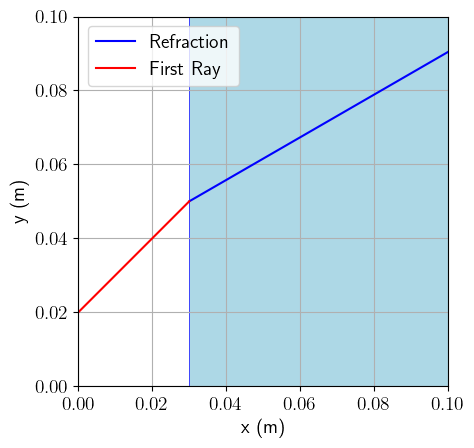

In [39]:
# Propagation from interface to the output plane (using propagation matrice)
yy0 = v2[0]
xx0 = x1
tt0 = v2[1]
v3 = np.array([x1, op])
d = op - x1 # Propagation distance
yy1 = yy0 + tan(tt0)*d  # calculating the final height
xx1 = op



# Create a square: (x, y) bottom-left corner, width, height
square = Rectangle((0.03, 0.0), 0.10, 0.10, 
                   edgecolor='blue', facecolor='lightblue', lw=0.5)

x__ = np.array([xx0, xx1])
y__ = np.array([yy0, yy1])
plt.figure()
plt.plot(x__,y__, 'b', label = 'Refraction')
plt.plot(x_,y_, 'r', label = 'First Ray')
plt.xlim(0, 0.1)
plt.ylim(0, 0.1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')

# Get current axes and add the rectangle
ax = plt.gca()
ax.add_patch(square)

# Optional: set square aspect or grid
ax.set_aspect('equal')   # if you want true square proportions
plt.grid(True)
plt.legend()
plt.show()

### Example 2 : Refraction at the transparent slab

In [40]:
z0 =  0.02 # first height
ti = 45 # first degree
tt = ti * pi/180 # degree to radians transformer
zi = 0.04 # first interface
y1 = z0 + tan(tt) * zi
xp = [0, zi] 
yp = [z0, y1]
v1 = np.array([y1, tt]) # creating y1, tt as an array
# plt.plot(xp, yp)
# plt.xlim(0, 0.1)
# plt.ylim(0, 0.1)

In [41]:
## Refraction at the first plane
n1 = 1
n2 = 1.5
d = 0.005 # thickness
M1 = np.array([[1, 0], 
              [0, n1/n2]])  # transformation matrix
v2 = M1 @ v1
y2 = y1 + tan(v2[1]) * d
# ploting
xpp = [zi, zi + d]
ypp = [y1, y2]

# plt.plot(xp, yp, xpp, ypp)
# plt.xlim(0, 0.1)
# plt.ylim(0, 0.1)

In [42]:
## Refraction at the second plane
n1 = 1.5
n2 = 1
M2 = np.array([[1, 0],
               [0, n1/n2]])
v3 = M @ v2
zii = zi + d + 0.95
y3 = y2 + tan(tt) * zii
xppp = [zi + d, zii]
yppp = [y2, y3]

# plt.plot(xp, yp, xpp, ypp, xppp, yppp, 'r')
# plt.xlim(0, 0.1)
# plt.ylim(0, 0.1)

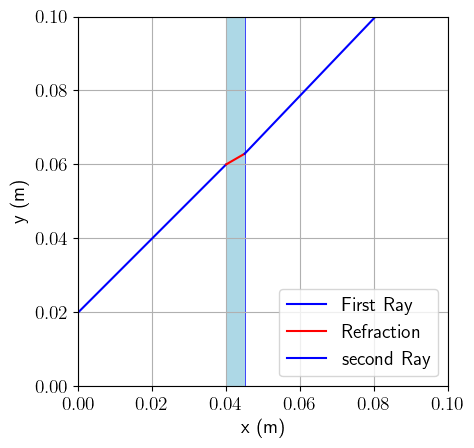

In [43]:
# Create a square: (x, y) bottom-left corner, width, height
square = Rectangle((zi, 0.0), d, 0.1,
                   edgecolor='blue', facecolor='lightblue', lw=0.5)

plt.figure()
plt.plot(xp,yp, 'b', label = 'First Ray')
plt.plot(xpp,ypp, 'r', label = 'Refraction')
plt.plot(xppp, yppp, 'b', label = 'second Ray')
plt.xlim(0, 0.1)
plt.ylim(0, 0.1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')

# Get current axes and add the rectangle
ax = plt.gca()
ax.add_patch(square)

# Optional: set square aspect or grid
ax.set_aspect('equal')   # if you want true square proportions
plt.grid(True)
plt.legend()
plt.show()

### Example 3 : Refraction of a bundle of parallel rays from an extended source at a planar interface

In [44]:
y0 = np.linspace(0.01, 0.03, 20)
ti = 45
tt = ti * pi/180
zi = 0.03
y1 = y0 + tan(tt) * zi
yp = [y0, y1]
xp = [np.zeros_like(y0), np.full_like(y1, zi)]
zii = 0.1
# plt.figure()
# plt.plot(xp, yp, 'b')
# plt.xlim(0, 0.1)
# plt.ylim(0, 0.1)
# plt.xlabel('x (m)')
# plt.ylabel('y (m)')


In [45]:
n1 = 1
n2 = 1.5
M = np.array([[1, 0],
              [0, n1/n2]])
theta1 = tan(tt) * np.ones_like(y1)   # incident slope for all rays
v1 = np.vstack([y1, theta1])    
v2 = M @ v1

y3 = v2[0] + v2[1] * (zii - zi) 

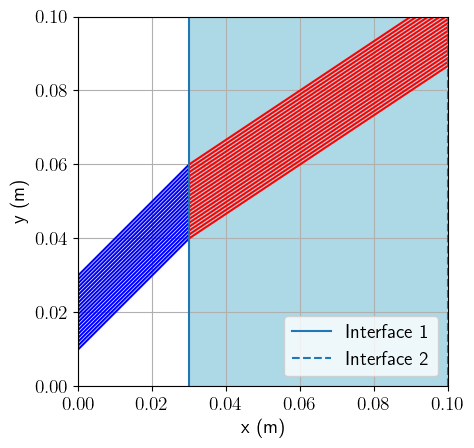

In [46]:
xpp = np.array([np.full_like(y0, zi), np.full_like(y0, zii)])  
ypp = np.array([y1, y3])  


square = Rectangle((zi, 0.0), zii - zi, 0.10, 
                   edgecolor='blue', facecolor='lightblue', lw=0.5)

# Plotting (unchanged except adding second interface line)
plt.figure()
plt.plot(xp, yp, 'b')   
plt.plot(xpp, ypp, 'r')
plt.xlim(0, 0.1)
plt.ylim(0, 0.1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axvline(x=zi, linestyle='-', label='Interface 1')
plt.axvline(x=zii, linestyle='--', label='Interface 2')   # added for clarity

ax = plt.gca()
ax.add_patch(square)
ax.set_aspect('equal')
plt.grid(True)
plt.legend()
plt.show()

In [47]:
y0 = 0.05
t = np.arange(-20, 20, 5)
tt = t * pi/180
zi = 0.04 # first interface
zii = 0.1 # second interface
y1 = y0 + np.tan(tt) * zi

xp = [ np.zeros_like(y1), np.full_like(y1, zi)]
yp = [np.full_like(y1, y0), y1]
# plt.figure()
# plt.plot(xp, yp, 'b')
# plt.xlim(0, 0.1)
# plt.ylim(0, 0.1)
# plt.xlabel('x (m)')
# plt.ylabel('y (m)')

In [48]:
# Refraction 
n1 = 1
n2 = 1.5
M = np.array([[1, 0],
              [0, n1/n2]])
theta1 = np.tan(tt) * np.ones_like(y1)   # incident angel for all rays
v1 = np.vstack([y1, theta1])    
v2 = M @ v1
y3 = v2[0] + np.tan(tt) * (zii - zi)

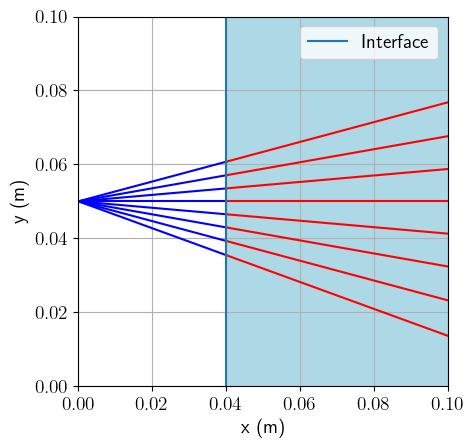

In [49]:
xpp = np.array([np.full_like(y0, zi), np.full_like(y0, zii)])  
ypp = np.array([y1, y3])  

square = Rectangle((zi, 0), zii - zi, 0.10,
                   edgecolor='blue', facecolor='lightblue', lw=0.5)


# plotting
plt.figure()
plt.plot(xp, yp, 'b')   
plt.plot(xpp, ypp, 'r')
plt.xlim(0, 0.1)
plt.ylim(0, 0.1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axvline(x=zi,linestyle='-', label='Interface')

# Get current axes and add the rectangle
ax = plt.gca()
ax.add_patch(square)

# Optional: set square aspect or grid
ax.set_aspect('equal')   # if you want true square proportions
plt.grid(True)
plt.legend()
plt.show()



### Example 5: Refraction of a bundle of parallel rays from a finite size source at a slab

In [50]:
N = 20
y0 = np.linspace(0.01, 0.03, N)
xi = 0.04
thickness = 0.005
ti = 45
tt = ti * pi/180
n1 = 1
n2 = 1.5
xii = 0.1   

def propagate(y0, theta, z):
    return y0 + tan(theta) * z

def refraction(y1, tt, n1, n2):
    v1 = np.array([y1, tt])
    M = np.array([[1, 0], [0, n1/n2]])
    v2 = M @ v1
    return v2[0], v2[1]

xp = []
yp = []
xpp = []
ypp = []
xppp = []
yppp = []


In [51]:

for i in range(N):
    y1 = propagate(y0[i], tt, xi)
    xp.append([0, xi])
    yp.append([y0[i], y1])

    y2, tt2 = refraction(y1, tt, n1, n2)
    y3 = propagate(y2, tt2, thickness)
    xpp.append([xi, xi + thickness])
    ypp.append([y1, y3])

    y4, tt3 = refraction(y3, tt2, n2, n1)

    y5 = propagate(y4, tt3, xii - (xi + thickness))   
    xppp.append([xi + thickness, xii])
    yppp.append([y4, y5])




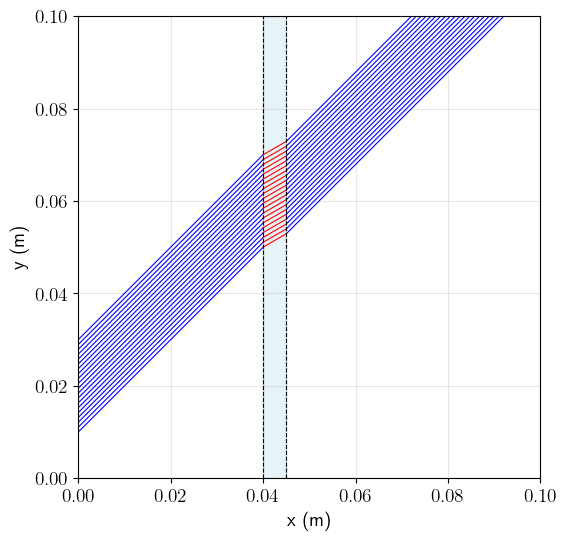

In [52]:
plt.figure(figsize=(8, 6))
for i in range(N):
    plt.plot(xp[i], yp[i], 'b', linewidth=0.8)   
    plt.plot(xpp[i], ypp[i], 'r', linewidth=0.8)  
    plt.plot(xppp[i], yppp[i], 'b', linewidth=0.8) 

rect = Rectangle((xi, 0), thickness, 0.1, facecolor='lightblue', alpha=0.3, edgecolor='gray')
plt.gca().add_patch(rect)

plt.axvline(x=xi, color='k', linestyle='--', linewidth=0.8)
plt.axvline(x=xi+thickness, color='k', linestyle='--', linewidth=0.8)

plt.xlim(0, 0.1)
plt.ylim(0, 0.1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid(alpha=0.3)
plt.gca().set_aspect('equal')
plt.show()

### Example 6: Refraction of a bundle of parallel rays from a point source at a slab

In [53]:
N = 10
y0 = 0.05
xi = 0.04
thickness = 0.005
ti = np.linspace(-20, 20, N)
tt = ti * np.pi/180
n1 = 1
n2 = 1.5
xii = 0.1   

def propagate(y0, theta, z):
    return y0 + np.tan(theta) * z

def refraction(y1, tt, n1, n2):
    v1 = np.array([y1, tt])
    M = np.array([[1, 0], [0, n1/n2]])
    v2 = M @ v1
    return v2[0], v2[1]

xp = []
yp = []
xpp = []
ypp = []
xppp = []
yppp = []


In [54]:
for i in range(N):
    y1 = propagate(y0, tt[i], xi)
    xp.append([0, xi])
    yp.append([y0, y1])

    y2, tt2 = refraction(y1, tt[i], n1, n2)
    y3 = propagate(y2, tt2, thickness)
    xpp.append([xi, xi + thickness])
    ypp.append([y1, y3])

    y4, tt3 = refraction(y3, tt2, n2, n1)

    y5 = propagate(y4, tt3, xii - (xi + thickness))   
    xppp.append([xi + thickness, xii])
    yppp.append([y4, y5])




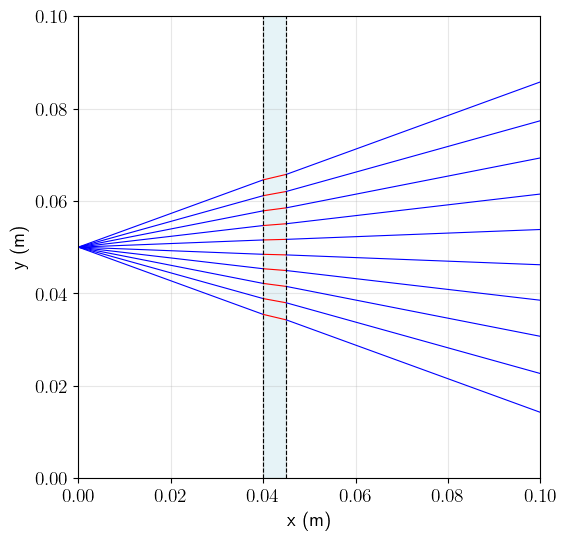

In [55]:
plt.figure(figsize=(8, 6))
for i in range(N):
    plt.plot(xp[i], yp[i], 'b', linewidth=0.8)   
    plt.plot(xpp[i], ypp[i], 'r', linewidth=0.8)  
    plt.plot(xppp[i], yppp[i], 'b', linewidth=0.8) 

rect = Rectangle((xi, 0), thickness, 0.1, facecolor='lightblue', alpha=0.3, edgecolor='gray')
plt.gca().add_patch(rect)

plt.axvline(x=xi, color='k', linestyle='--', linewidth=0.8)
plt.axvline(x=xi+thickness, color='k', linestyle='--', linewidth=0.8)

plt.xlim(0, 0.1)
plt.ylim(0, 0.1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid(alpha=0.3)
plt.gca().set_aspect('equal')
plt.show()

### Example 7 -- Focusing a bundle of paraxial rays by a convex lens

In [56]:
N = 10
y0 = np.linspace(-0.025, 0.025, N)
x0 = 0
d1 = 0.05
d2 = 0.3
f = 0.15
ti = 0
tt = ti * pi/180

def propagate(y0, tt, d):
    y1 = y0 + tan(tt) * d
    return y1
def lens(f, y1, tt):
    v1 = np.array([y1, tt])
    M = np.array([[1, 0],
                 [-1/f, 1]])
    v2 = M@v1
    return v2

xp = []
yp = []
xpp = []
ypp = []


In [57]:
for i in range(N):
    y1 = propagate(y0[i], tt, d1)

    yp.append([y0[i], y1])
    xp.append([x0, d1]) 

    
    l1 = lens(f, y1, tt)
    y2 = propagate(l1[0], l1[1], d2 - d1)
    
    ypp.append([y1, y2])
    xpp.append([d1, d2])

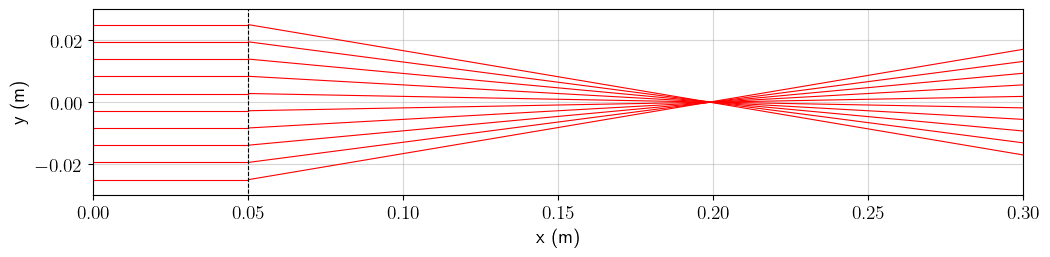

In [58]:
plt.figure(figsize=(12, 8))
for i in range(N):
    plt.plot(xp[i], yp[i], 'r', linewidth=0.8)
    plt.plot(xpp[i], ypp[i], 'r', linewidth=0.8)


plt.plot([d1, d1], [-0.1, 0.1], 'k--', linewidth=0.8, label='Lens plane')
plt.xlim(0, 0.3)
plt.ylim(-0.03, 0.03)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid(alpha=0.5)
plt.gca().set_aspect('equal')
plt.show()

### Example 8 -- Focusing a bundle of rays by a convex lens: Effect of spherical aberrations

In [59]:
N = 40
y0 = np.linspace(-0.1, 0.1, N)
x0 = 0
d1 = 0.05
d2 = 0.4
f = 0.15
ti = 0
tt = ti * pi/180



xp = []
yp = []
xpp = []
ypp = []

def propagate(y0, tt, d):
    y1 = y0 + tan(tt)*d  # ray height after propagation
    return y1

def lens(f, y1, tt):
    v1 = np.array([y1, tt])
    M = np.array([[1, 0],
                  [-1/f, 1]])
    v2 = M @ v1
    return v2

In [60]:
for i in range(N):
    y1 = propagate(y0[i], tt, d)
    
    yp.append([y0[i], y1])
    xp.append([x0, d1])
    
    l1 = lens(f, y1, tt)
    y2 = propagate(l1[0], l1[1], d2 - d1)
    
    ypp.append([y1, y2])
    xpp.append([d1, d2])

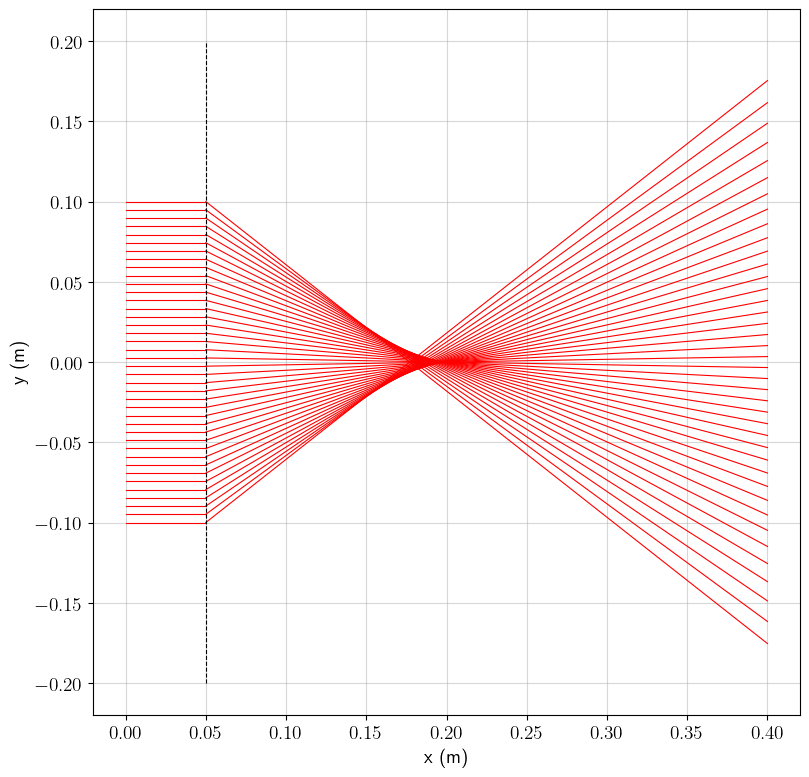

In [61]:
plt.figure(figsize=(12, 8))
for i in range(N):
    plt.plot(xp[i], yp[i], 'r', linewidth=0.8)
    plt.plot(xpp[i], ypp[i], 'r', linewidth=0.8)


plt.plot([d1, d1], [-0.20, 0.20], 'k--', linewidth=0.8, label='Lens plane')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid(alpha=0.5)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

### Example 9 -- Focusing a bundle of rays by a convex lens: Oblique incidence, coma, and spherical aberrations

In [62]:
N = 10
y0 = np.linspace(-0.15, 0, N)
x0 = 0
f = 0.15
d1 = 0.05
d2 = 0.4
ti = 20
tt = ti * pi/180



xp = []
yp = []
xpp = []
ypp = []
def propagate(y0, tt, d):
    y1 = y0 + tan(tt) * d
    return y1

def lens(f, y0, tt):
    v1 = np.array([y0, tt])
    M = np.array([[1, 0],
                  [-1/f, 1]])
    
    v2 = M @ v1
    return v2


In [63]:
for i in range(N):
    y1 = propagate(y0[i], tt, d1)

    xp.append([x0, d1])
    yp.append([y0[i], y1])

    l1 = lens(f, y1, tt)
    y2 = propagate(l1[0], l1[1], d2 - d1)
    
    ypp.append([y1, y2])
    xpp.append([d1, d2])


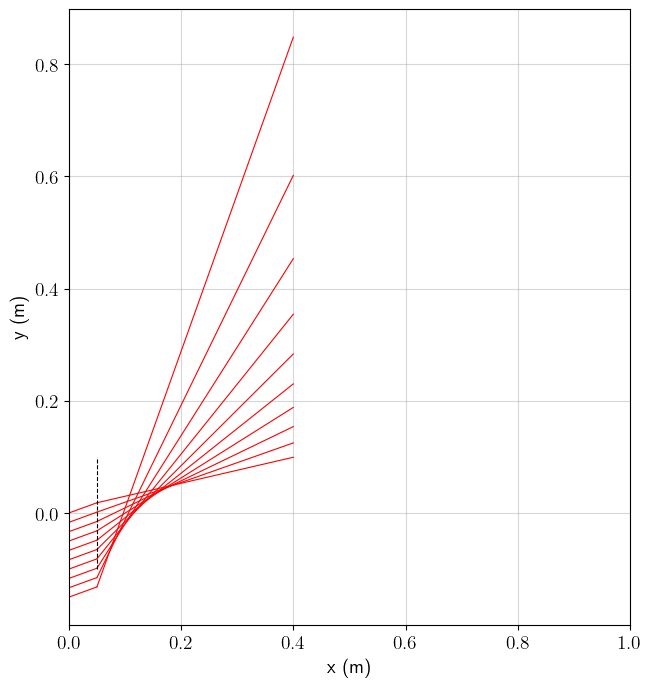

In [64]:
plt.figure(figsize=(12, 8))
for i in range(N):
    plt.plot(xp[i], yp[i], 'r', linewidth=0.8)
    plt.plot(xpp[i], ypp[i], 'r', linewidth=0.8)


plt.plot([d1, d1], [-0.1, 0.1], 'k--', linewidth=0.8, label='Lens plane')
plt.xlim(0, 1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid(alpha=0.5)
plt.gca().set_aspect('equal')
plt.show()

### Example 10 -- Image formation, point object at focus

In [65]:
N = 10
y0 = 0
x0 = 0
f = 0.15
d1 = 0.15
d2 = 0.4
ti = np.linspace(-20, 20, N)
tt = ti * np.pi/180



xp = []
yp = []
xpp = []
ypp = []
def propagate(y0, tt, d):
    y1 = y0 + tan(tt) * d
    return y1

def lens(f, y0, tt):
    v1 = np.array([y0, tt])
    M = np.array([[1, 0],
                  [-1/f, 1]])
    
    v2 = M @ v1
    return v2


In [66]:
for i in range(N):
    y1 = propagate(y0, tt[i], d1)

    xp.append([x0, d1])
    yp.append([y0, y1])

    l1 = lens(f, y1, tt[i])
    y2 = propagate(l1[0], l1[1], d2 - d1)
    
    ypp.append([y1, y2])
    xpp.append([d1, d2])


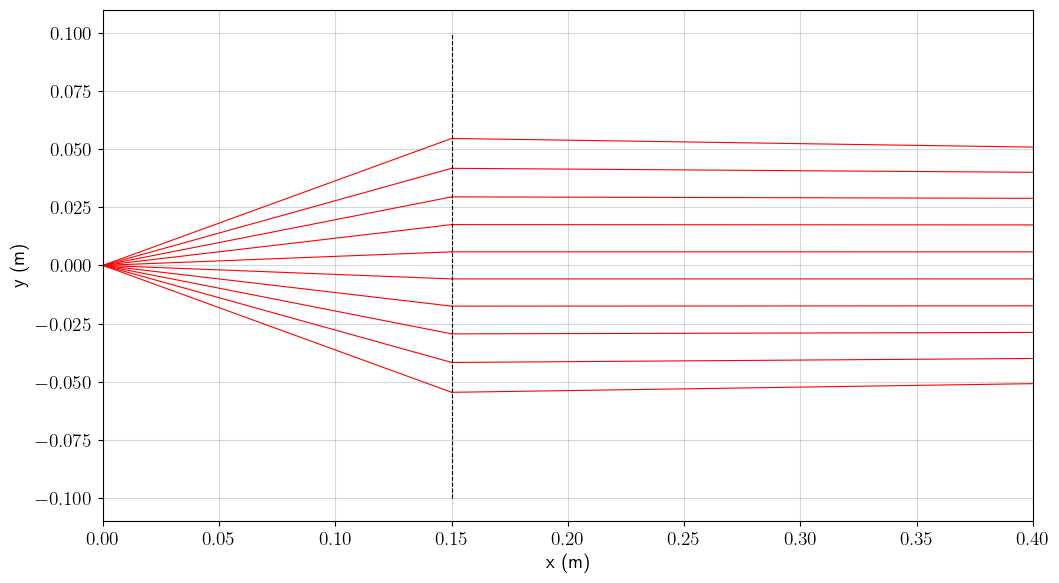

In [67]:
plt.figure(figsize=(12, 8))
for i in range(N):
    plt.plot(xp[i], yp[i], 'r', linewidth=0.8)
    plt.plot(xpp[i], ypp[i], 'r', linewidth=0.8)


plt.plot([d1, d1], [-0.1, 0.1], 'k--', linewidth=0.8, label='Lens plane')
plt.xlim(0, 0.4)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid(alpha=0.5)
plt.gca().set_aspect('equal')
plt.show()

### Example 11 -- Image formation

In [68]:
N = 3
ti = np.linspace(-2, 2, N)
tt = ti * pi/ 180
y0_0 = 0
y0_1 = 0.01
f = 0.05
d1 = 0.15
d2 = 0.3
x0 = 0

xp0 = []
yp0 = []
xpp0 = []
ypp0 = []

xp1 = []
yp1 = []
xpp1 = []
ypp1 = []

def propagate(y0, tt, d):
    y1 = y0 + tan(tt) * d
    return y1

def lens(f, y0, tt):
    v1 = np.array([y0, tt])
    M = np.array([[1, 0],
                  [-1/f, 1]])
    
    v2 = M @ v1
    return v2

In [69]:
for i in range(N):
    y1_0 = propagate(y0_0, tt[i], d1)
    y1_1 = propagate(y0_1, tt[i], d1)
    xp0.append([x0, d1])
    yp0.append([y0_0, y1_0])
    xp1.append([x0, d1])
    yp1.append([y0_1, y1_1])
    l1_0 = lens(f, y1_0, tt[i])
    l1_1 = lens(f, y1_1, tt[i])
    y2_0 = propagate(l1_0[0], l1_0[1], d2 - d1)
    y2_1 = propagate(l1_1[0], l1_1[1], d2 - d1)
    ypp0.append([y1_0, y2_0])
    xpp0.append([d1, d2])
    ypp1.append([y1_1, y2_1])
    xpp1.append([d1, d2])
    

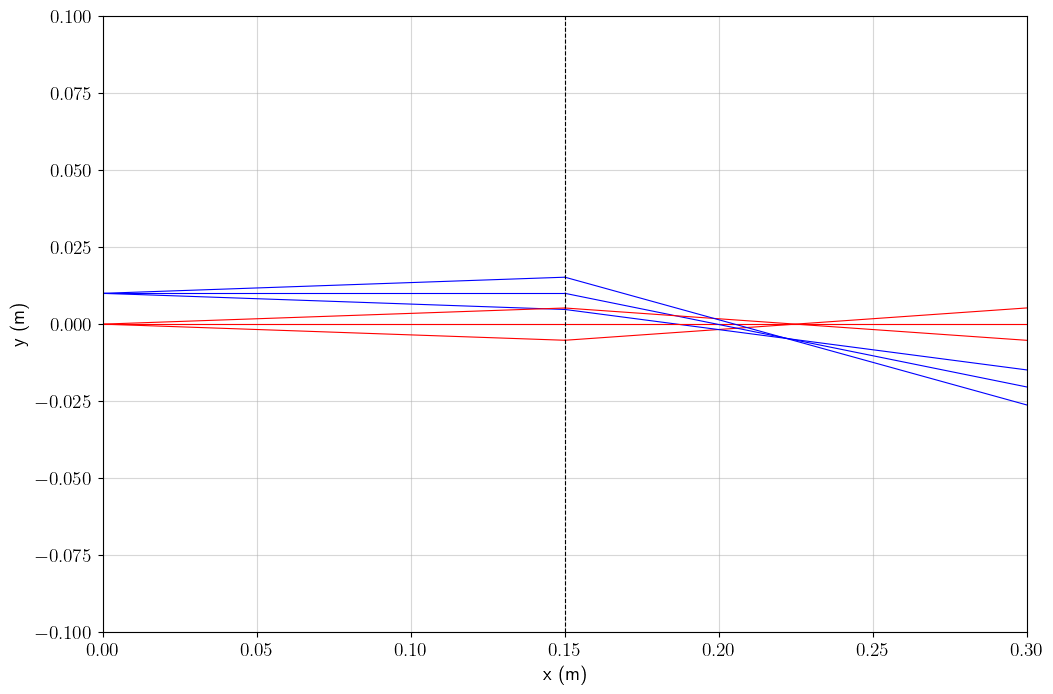

In [70]:
plt.figure(figsize=(12, 8))
for i in range(N):
    plt.plot(xp0[i], yp0[i], 'r', linewidth=0.8)
    plt.plot(xpp0[i], ypp0[i], 'r', linewidth=0.8)
    plt.plot(xp1[i], yp1[i], 'b', linewidth=0.8)
    plt.plot(xpp1[i], ypp1[i], 'b', linewidth=0.8)



plt.plot([d1, d1], [-0.1, 0.1], 'k--', linewidth=0.8, label='Lens plane')

plt.xlim(0, 0.3)
plt.ylim(-0.1, 0.1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid(alpha=0.5)
plt.gca().set_aspect('equal')
plt.show()

### Example 12 -- Flat Mirror: Reflection from a flat mirror 

In [71]:
N = 20
y0 = 0 
ti = np.linspace(0, 20, N)
tt = ti * pi/ 180
d1 = 0.1
d2 = 0.25
x0 = 0

xp = []
xpp = []
xpp_v = []
yp = []
ypp = []
ypp_v = []

def propagate(y0, tt, d):
    return y0 + tan(tt)*d

def flat_mirror(y, tt):
    v1 = np.array([y, tt])
    M = np.array([[1, 0],
                  [0, 1]])
    v2 = M @ v1

    return v2


In [72]:
for i in range(N):
    y1 = propagate(y0, tt[i], d1)
    xp.append([x0, d1])
    yp.append([y0, y1])
    y2 = flat_mirror(y1, tt[i])
    y3 = propagate(y2[0], tt[i], d1)
    xpp.append([d1, x0])
    ypp.append([y2[0], y3])

    y4 = propagate(y2[0], -tt[i],d2 - d1)
    xpp_v.append([d1, d2])
    ypp_v.append([y2[0], y4])

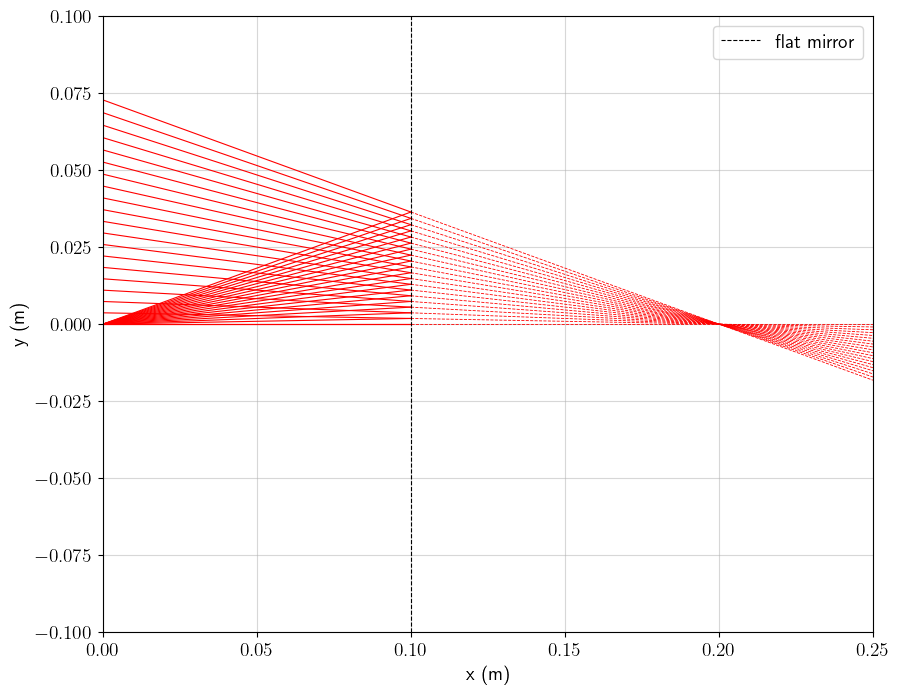

In [73]:
plt.figure(figsize=(12, 8))
for i in range(N):
    plt.plot(xp[i], yp[i], 'r', linewidth=0.8)
    plt.plot(xpp[i], ypp[i], 'r', linewidth=0.8)
    plt.plot(xpp_v[i], ypp_v[i], 'r--', linewidth =0.6)


plt.plot([d1, d1], [-0.1, 0.1], 'k--', linewidth=0.8, label='flat mirror')
plt.xlim(0, d2)
plt.ylim(-0.1, 0.1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid(alpha=0.5)
plt.gca().set_aspect('equal')
plt.legend()
plt.show()

### Example 13 -- Spherical Mirror: Reflection from a convex mirror

In [74]:
N = 20
y0 = np.linspace(-0.04, 0.04, N)
ti = 0
tt = ti * pi/ 180
d1 = 0.3
d2 = 0.3
x0 = 0
R = 0.4

xp = []
xpp = []
yp = []
ypp = []


def propagate(y0, tt, d):
    return y0 + tan(tt)*d

def Spherical_mirror(y, tt, R):
    v1 = np.array([y, tt])
    M = np.array([[1, 0],
                  [2/R, 1]])
    v2 = M @ v1

    return v2


In [75]:
for i in range(N):
    y1 = propagate(y0[i], tt, d1)
    xp.append([x0, d1])
    yp.append([y0[i], y1])
    y2 = Spherical_mirror(y1, tt, R)
    y3 = propagate(y2[0], y2[1], d2)
    xpp.append([d2, x0])
    ypp.append([y2[0], y3])



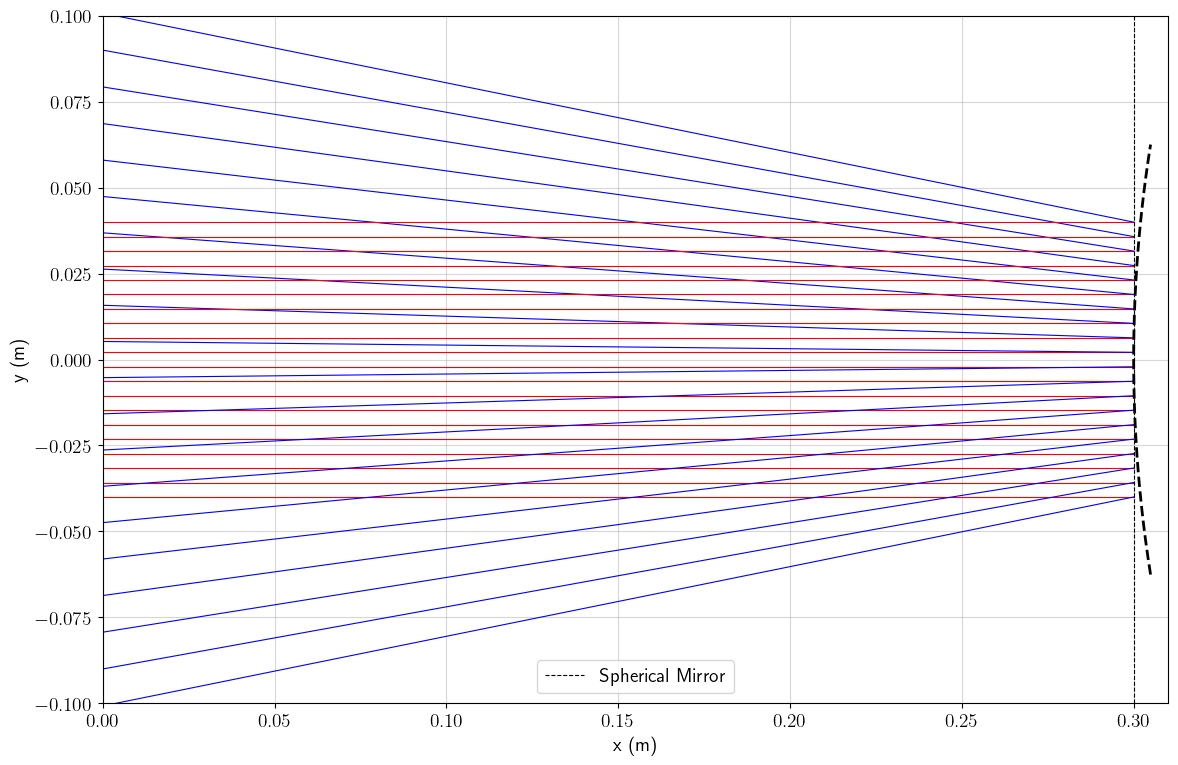

In [76]:
plt.figure(figsize=(12, 8))
for i in range(N):
    plt.plot(xp[i], yp[i], 'r', linewidth=0.8)
    plt.plot(xpp[i], ypp[i], 'b', linewidth=0.8)


t = np.linspace(-pi/20, pi/20, 1024)   
zc = 0.7
yc = 0


z = zc - R * np.cos(t)
y = yc + R * np.sin(t)


plt.plot(z, y, linewidth=2, linestyle='--', color='k')
plt.plot([d1, d1], [-0.1, 0.1], 'k--', linewidth=0.8, label='Spherical Mirror')
plt.xlim(0, 0.31)
plt.ylim(-0.1, 0.1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid(alpha=0.5)
plt.gca().set_aspect('equal')
plt.legend()

plt.tight_layout()
plt.show()

### Example 14 -- A Beam expander composed of two convex lenses

In [77]:
N = 10
y0 = np.linspace(-0.025, 0.025, N)
x0 = 0
d1 = 0.1
d2 = 0.5
d3 = 0.65
f1 = 0.1
f2 = 0.3
ti = 0
tt = ti * pi/180

def propagate(y0, tt, d):
    y1 = y0 + tan(tt) * d
    return y1
def lens(f, y1, tt):
    v1 = np.array([y1, tt])
    M = np.array([[1, 0],
                 [-1/f, 1]])
    v2 = M@v1
    return v2

xp = []
yp = []
xpp = []
ypp = []
xppp = []
yppp = []

In [78]:
for i in range(N):
    y1 = propagate(y0[i], tt, d1)

    yp.append([y0[i], y1])
    xp.append([x0, d1]) 

    
    l1 = lens(f1, y1, tt)
    y2 = propagate(l1[0], l1[1], d2 - d1)
    
    ypp.append([y1, y2])
    xpp.append([d1, d2])

    l2 = lens(f2, y2, l1[1])
    y3 = propagate(l2[0], l2[1], d3 - d2)

    yppp.append([y2, y3])
    xppp.append([d2, d3])


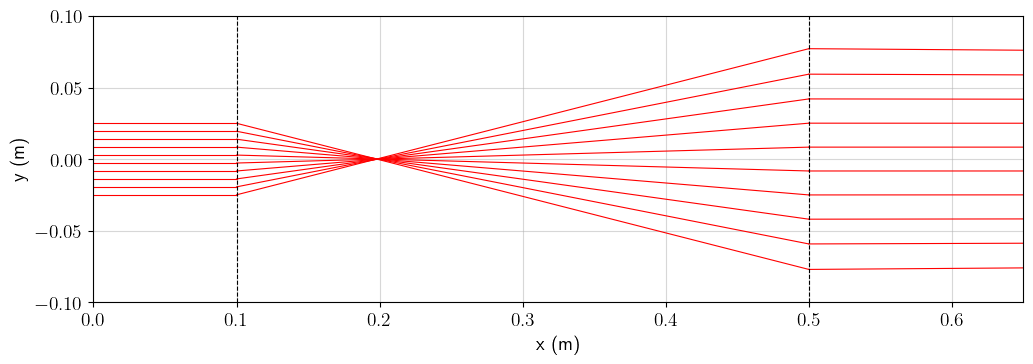

In [79]:
plt.figure(figsize=(12, 8))
for i in range(N):
    plt.plot(xp[i], yp[i], 'r', linewidth=0.8)
    plt.plot(xpp[i], ypp[i], 'r', linewidth=0.8)
    plt.plot(xppp[i], yppp[i], 'r', linewidth=0.8)


plt.plot([d1, d1], [-0.1, 0.1], 'k--', linewidth=0.8, label='Lens plane')
plt.plot([d2, d2], [-0.1, 0.1], 'k--', linewidth=0.8, label='Lens plane')
plt.xlim(0, 0.65)
plt.ylim(-0.1, 0.1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid(alpha=0.5)
plt.gca().set_aspect('equal')
plt.show()


### Example 15 -- A Beam expander composed of a convex and a concave

In [80]:
N = 10
y0 = np.linspace(-0.025, 0.025, N)
x0 = 0
d1 = 0.1
d2 = 0.3
d3 = 0.65
f1 = -0.1
f2 = 0.3
ti = 0
tt = ti * pi/180

def propagate(y0, tt, d):
    y1 = y0 + tan(tt) * d
    return y1
def lens(f, y1, tt):
    v1 = np.array([y1, tt])
    M = np.array([[1, 0],
                 [-1/f, 1]])
    v2 = M@v1
    return v2

xp = []
yp = []
xpp = []
ypp = []
xppp = []
yppp = []

In [81]:
for i in range(N):
    y1 = propagate(y0[i], tt, d1)

    yp.append([y0[i], y1])
    xp.append([x0, d1]) 

    
    l1 = lens(f1, y1, tt)
    y2 = propagate(l1[0], l1[1], d2 - d1)
    
    ypp.append([y1, y2])
    xpp.append([d1, d2])

    l2 = lens(f2, y2, l1[1])
    y3 = propagate(l2[0], l2[1], d3 - d2)

    yppp.append([y2, y3])
    xppp.append([d2, d3])


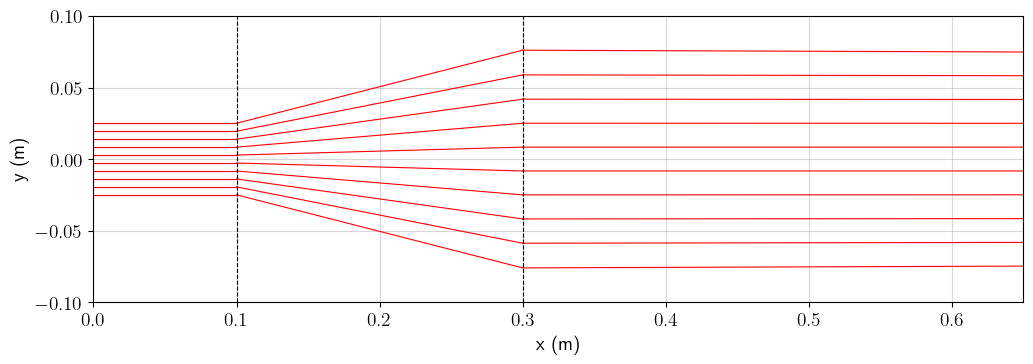

In [82]:
plt.figure(figsize=(12, 8))
for i in range(N):
    plt.plot(xp[i], yp[i], 'r', linewidth=0.8)
    plt.plot(xpp[i], ypp[i], 'r', linewidth=0.8)
    plt.plot(xppp[i], yppp[i], 'r', linewidth=0.8)


plt.plot([d1, d1], [-0.1, 0.1], 'k--', linewidth=0.8, label='Lens plane')
plt.plot([d2, d2], [-0.1, 0.1], 'k--', linewidth=0.8, label='Lens plane')
plt.xlim(0, 0.65)
plt.ylim(-0.1, 0.1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid(alpha=0.5)
plt.gca().set_aspect('equal')
plt.show()


### Example 16 -- Cascaded Components: Beam Expander

In [83]:
z0 = 0                    
zi1 = 0.1                
z1 = np.array([z0, zi1])  
Nr = 11                 
ttd = 0                   
ti = ttd * np.pi / 180    
r01 = np.linspace(-0.02, 0.02, Nr)
f1 = -0.1                
zi2 = 0.3             
d = zi2 - zi1             
f2 = 0.3                  
zf = 0.65                 
z2 = np.array([zi1, zf])  


M1 = np.array([[1, 0],
               [-1/f1, 1]])         
M2 = np.array([[1, d],
               [0, 1]])           
M3 = np.array([[1, 0],
               [-1/f2, 1]])        

Mt = M3 @ M2 @ M1                  



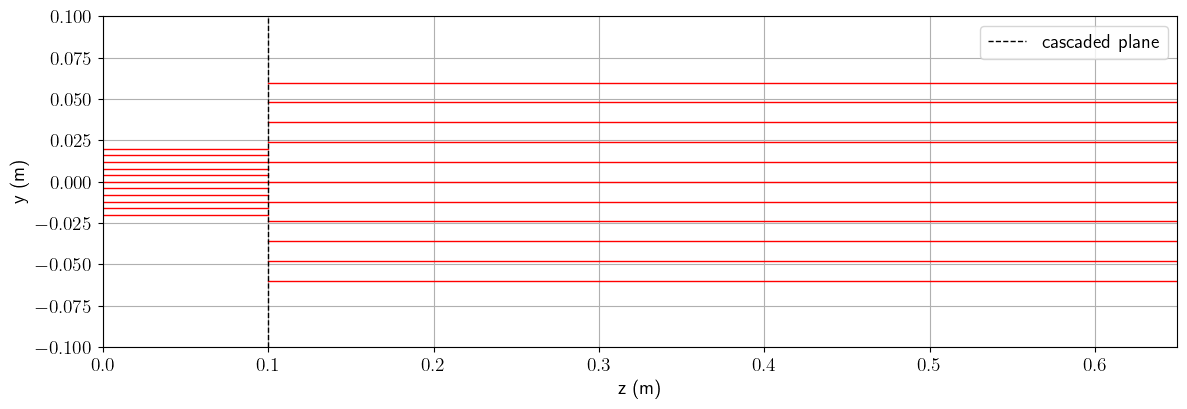

In [84]:
plt.figure(figsize=(12, 8))
for n in range(Nr):
    r0 = r01[n]
  
    r1 = r0 + np.tan(ti) * z1        

    v1 = np.array([r1[1], ti])       
    
    v2 = Mt @ v1                     

    r2 = v2[0] + np.tan(v2[1]) * (z2 - z2[0])

    plt.plot(z1, r1, 'r', linewidth=1)
    plt.plot(z2, r2, 'r', linewidth=1)


plt.plot([zi1, zi1], [-0.1, 0.1], 'k--', linewidth=1, label='cascaded plane')
plt.grid(True)
plt.gca().set_aspect('equal')
plt.xlim(0, zf)
plt.ylim(-0.1, 0.1)
plt.xlabel('z (m)')
plt.ylabel('y (m)')
plt.legend()
plt.tight_layout()
plt.show()

### Example 17: Rays Of a Parabolic Wavefront

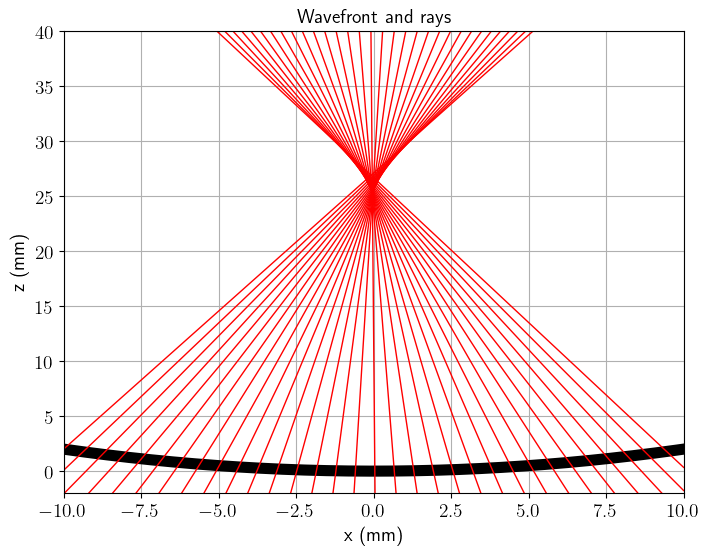

In [85]:
N = 256
x = np.linspace(-10, 10, N) # making a gird

#-- creating wavefronts
a = [0, 0, 0, 0.02, 0, 0] # poly variables
y = np.polyval(a, x)  # equivalent to 0.02 * x**2
# plt.plot(x, y)

u = np.diff(y) / np.diff(x) # numerical derivative

M = np.full((N,N), np.nan)
p = 8
for n in range(0, N-1, p):
    slope_normal = -1.0/u[n] # slope_nurmal*u = -1
    q = y[n] + slope_normal*(x - x[n])
    M[:,n] = q

# -- plotting
plt.figure(figsize=(8, 6))
# wavefront (thick black line)
p1, = plt.plot(x, y, 'k-', linewidth=8, label='Wavefront')
# Plot rays each column of M that is not all NaN
for n in range(0, N, p):
    if not np.all(np.isnan(M[:, n])):
        plt.plot(x, M[:, n], 'r-', linewidth=1)

# Axis settings
plt.xlim(-10, 10)
plt.ylim(-2, 40)
plt.xticks(np.arange(-10, 12.5, 2.5))
plt.yticks(np.arange(0, 45, 5))
plt.xlabel('x (mm)')
plt.ylabel('z (mm)')
plt.grid(True)
plt.box(True)
plt.gca().tick_params(labelsize=14)
plt.gca().tick_params(axis='both', which='major', labelsize=14)
plt.gca().set_title('Wavefront and rays', fontsize=14)
plt.show()

### Example 18: Rays of a Conical Wavefront
#### A Conical wavefront can be generated by an axicon for instance

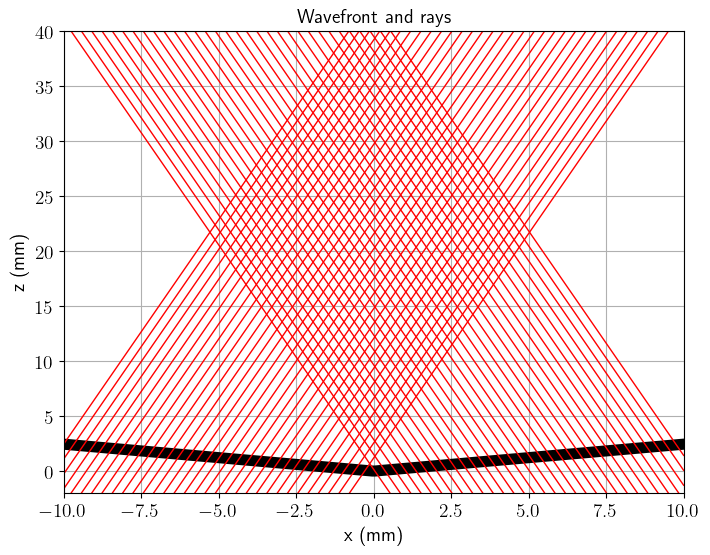

In [86]:
N = 256

x = np.linspace(-10, 10, N)

a = 0.245
y = a * np.abs(x)
# plt.plot(x, y)

u = np.diff(y)/ np.diff(x)
M = np.full((N,N), np.nan)

p = 4
for i in range(0, N, p):
    slope_normal = -1/u[i]
    q = y[i] + slope_normal * (x - x[i])
    M[:,i] = q

# -- plotting
plt.figure(figsize=(8, 6))
# wavefront (thick black line)
p1, = plt.plot(x, y, 'k-', linewidth=8, label='Wavefront')
# Plot rays each column of M that is not all NaN
for n in range(0, N, p):
    if not np.all(np.isnan(M[:, n])):
        plt.plot(x, M[:, n], 'r-', linewidth=1)

# Axis settings
plt.xlim(-10, 10)
plt.ylim(-2, 40)
plt.xticks(np.arange(-10, 12.5, 2.5))
plt.yticks(np.arange(0, 45, 5))
plt.xlabel('x (mm)')
plt.ylabel('z (mm)')
plt.grid(True)
plt.box(True)
plt.gca().tick_params(labelsize=14)
plt.gca().tick_params(axis='both', which='major', labelsize=14)
plt.gca().set_title('Wavefront and rays', fontsize=14)
plt.show()

### Example 19

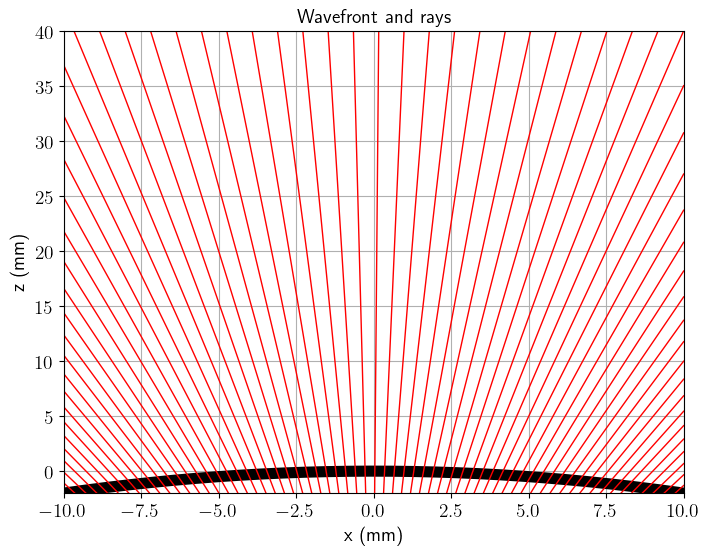

In [87]:
N = 256

x = np.linspace(-10, 10, N)

y = -0.02*x**2
# plt.plot(x, y)

u = np.diff(y)/ np.diff(x)
M = np.full((N,N), np.nan)

p = 4
for i in range(0, N, p):
    slope_normal = -1/u[i]
    q = y[i] + slope_normal * (x - x[i])
    M[:,i] = q

# -- plotting
plt.figure(figsize=(8, 6))
# wavefront (thick black line)
p1, = plt.plot(x, y, 'k-', linewidth=8, label='Wavefront')
# Plot rays each column of M that is not all NaN
for n in range(0, N, p):
    if not np.all(np.isnan(M[:, n])):
        plt.plot(x, M[:, n], 'r-', linewidth=1)

# Axis settings
plt.xlim(-10, 10)
plt.ylim(-2, 40)
plt.xticks(np.arange(-10, 12.5, 2.5))
plt.yticks(np.arange(0, 45, 5))
plt.xlabel('x (mm)')
plt.ylabel('z (mm)')
plt.grid(True)
plt.box(True)
plt.gca().tick_params(labelsize=14)
plt.gca().tick_params(axis='both', which='major', labelsize=14)
plt.gca().set_title('Wavefront and rays', fontsize=14)
plt.show()

## 3.2 Problems

### 3.2.1
Perform a numerical ray-tracing analysis for the following cases:

a. Reflection of a bundle of parallel rays at a concave mirror of radius R .

b. Refraction of a bundle of parallel rays at a spherical interface.

In [88]:
N = 20
y0 = np.linspace(-0.04, 0.04, N)
ti = 0
tt = ti * np.pi/180
R = 0.4
f = R/2
d1 = 0.3
d2 = 0.15
x0 = 0

xp = []
yp = []
xpp = []
ypp = []
xppp = []
yppp = []


def propagate(y0, tt, d):
    y2 = y0 + tan(tt) * d
    return y2

def Spherical_mirror(y, tt, R):
    v1 = np.array([y, tt])
    M = np.array([[1, 0],
                  [-2/R, 1]])
    v2 = M @ v1

    return v2

In [89]:
for i in range(N):
    y1 = propagate(y0[i], tt, d1)
    xp.append([x0, d1])
    yp.append([y0[i], y1])
    v2 = Spherical_mirror(y1, tt, R)
    y2 = propagate(v2[0], v2[1], f)
    xpp.append([d1, f])
    ypp.append([y1, y2])
    y3 = propagate(y2, v2[1], f - d2)
    xppp.append([f, d2])
    yppp.append([y2, y3])

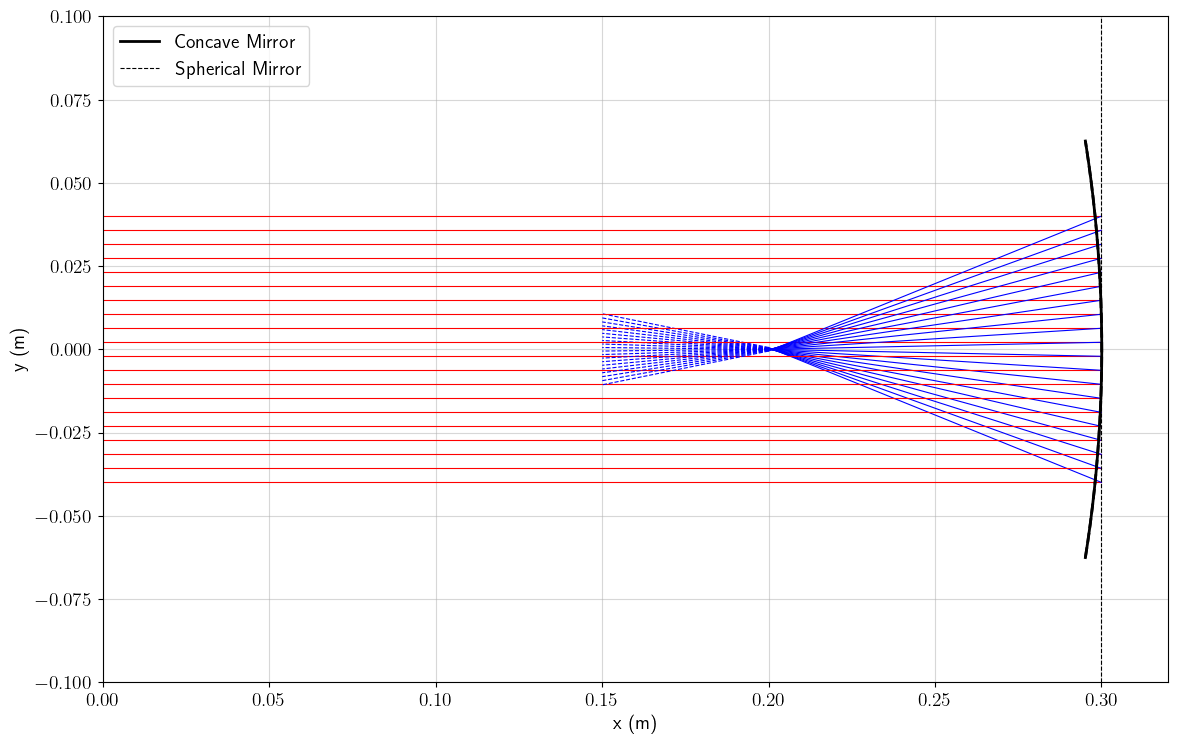

In [90]:
plt.figure(figsize=(12, 8))
for i in range(N):
    plt.plot(xp[i], yp[i], 'r', linewidth=0.8)
    plt.plot(xpp[i], ypp[i], 'b', linewidth=0.8)
    plt.plot(xppp[i], yppp[i], 'b--', linewidth=0.8)

t = np.linspace(-np.pi/20, np.pi/20, 1024)

x_vertex = 0.3001          # mirror pole (vertex)               # radius of curvature
zc = x_vertex - R       # center of curvature (left of vertex)
yc = 0

z = zc + R * np.cos(t)   # concave arc (vertex at rightmost)
y = yc + R * np.sin(t)

plt.plot(z, y, 'k-', linewidth=2, label='Concave Mirror')
plt.plot(z, y, linewidth=2, linestyle='--', color='k')
plt.plot([d1, d1], [-0.1, 0.1], 'k--', linewidth=0.8, label='Spherical Mirror')
plt.xlim(0, 0.32)
plt.ylim(-0.1, 0.1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid(alpha=0.5)
plt.gca().set_aspect('equal')
plt.legend()
plt.tight_layout()
plt.show()

In [91]:
N = 10
y0 = np.linspace(0.04, 0.06, N)
xi = 0.04
thickness = 0.055
ti = 10
tt = ti * pi/180
n1 = 1
n2 = 1.5
xii = 0.2   
R = 0.4

xp = []
yp = []
xpp = []
ypp = []
xppp = []
yppp = []


def propagate(y0, theta, z):
    return y0 + tan(theta) * z

def refraction_spherical(y1, tt, n1, n2, R):
    v1 = np.array([y1, tt])
    M = np.array([[1, 0], [-(n2-n1)/(n2*R), n1/n2]])
    v2 = M @ v1
    return v2[0], v2[1]

def refraction(y1, tt, n1, n2):
    v1 = np.array([y1, tt])
    M = np.array([[1, 0], [0, n1/n2]])
    v2 = M @ v1
    return v2[0], v2[1]

In [92]:
for i in range(N):
    y1 = propagate(y0[i], tt, xi)
    xp.append([0, xi])
    yp.append([y0[i], y1])

    y2, tt2 = refraction_spherical(y1, tt, n1, n2,R)
    y3 = propagate(y2, tt2, thickness)
    xpp.append([xi, xi + thickness])
    ypp.append([y1, y3])

    y4, tt3 = refraction(y3, tt2, n2, n1)

    y5 = propagate(y4, tt3, xii - (xi + thickness))   
    xppp.append([xi + thickness, xii])
    yppp.append([y4, y5])




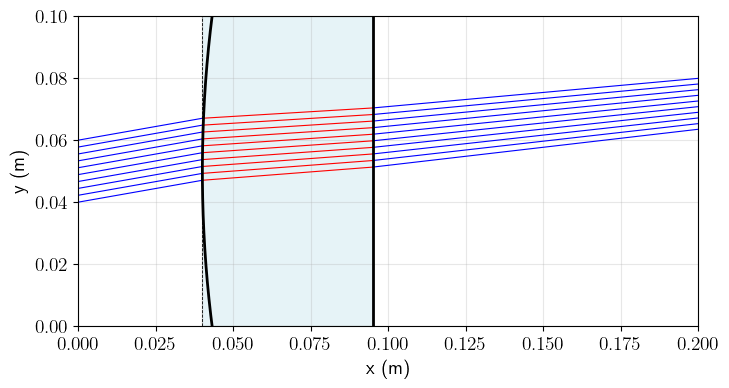

In [93]:
plt.figure(figsize=(8, 6))
for i in range(N):
    plt.plot(xp[i], yp[i], 'b', linewidth=0.8)   
    plt.plot(xpp[i], ypp[i], 'r', linewidth=0.8)  
    plt.plot(xppp[i], yppp[i], 'b', linewidth=0.8) 

rect = Rectangle((xi, 0), thickness, 0.1, facecolor='lightblue', alpha=0.3, edgecolor='gray')
t = np.linspace(-pi/20, pi/20, 1024)   
zc = R + xi
yc = 0.05


z = zc - R * np.cos(t)
y = yc + R * np.sin(t)


plt.plot(z, y, linewidth=2, linestyle='-', color='k')
plt.gca().add_patch(rect)

plt.axvline(x=xi, color='k', linestyle='--', linewidth=0.6)
plt.axvline(x=xi+thickness, color='k', linestyle='-', linewidth=2)

plt.xlim(0, 0.2)
plt.ylim(0.0, 0.1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid(alpha=0.3)
plt.gca().set_aspect('equal')
plt.show()

### 3.2.2

Through numerical ray-tracing, investigate image formation by a simple microscopy system

- See “Introduction to Optics, Section 3.6 (F. L. Pedrotti et al., Pearson 2006 [3rd Ed])” for more information on simple microscopy systems.

In [94]:
N = 20
y0 = -0.005
y1 = 0.005
y_object = [y0, y1]          
ti = np.linspace(-5, 5, N)
tt = ti * pi / 180
x0 = 0
d1 = 0.06    
d2 = 0.2     
d3 = 0.05    
f1 = 0.05   
f2 = 0.1   
  
def propagate(y, tt, d):
    y2 = y + tan(tt) * d
    return y2

def transmission_lens(y, tt, f):
    v1 = np.array([y, tt])
    M = np.array([[1, 0],
                  [-1/f, 1]])
    v2 = M @ v1
    return v2



In [95]:
rays_x = []
rays_y = []

for y in y_object:            # corrected variable name
    for t in tt:
        x_points = []
        y_points = []

        x_points.append(x0)
        y_points.append(y)      # corrected: append the current y, not the whole list

        y1 = propagate(y, t, d1)
        x_points.append(d1)
        y_points.append(y1)

        v2 = transmission_lens(y1, t, f1)   # v2 = [y, new_angle]
        y3 = propagate(v2[0], v2[1], d2)
        x_points.append(d1 + d2)
        y_points.append(y3)

        v4 = transmission_lens(y3, v2[1], f2)  # using angle after first lens
        y5 = propagate(v4[0], v4[1], d3)
        x_points.append(d1 + d2 + d3)
        y_points.append(y5)

        rays_x.append(x_points)
        rays_y.append(y_points)



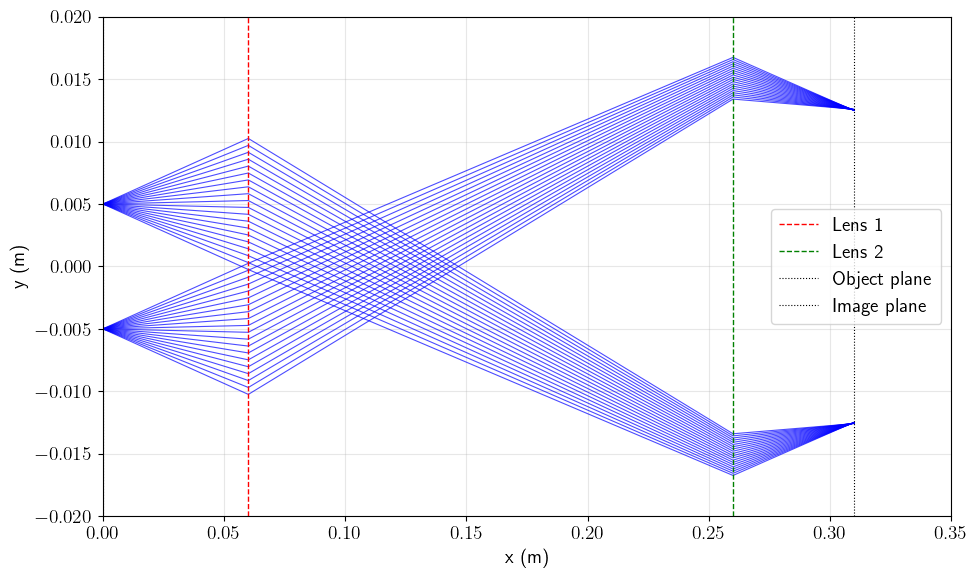

In [96]:
plt.figure(figsize=(10, 6))

for i in range(len(rays_x)):
    plt.plot(rays_x[i], rays_y[i], 'b-', linewidth=0.8, alpha=0.7)

plt.axvline(x=d1, color='r', linestyle='--', linewidth=1, label='Lens 1')
plt.axvline(x=d1+d2, color='g', linestyle='--', linewidth=1, label='Lens 2')
plt.axvline(x=x0, color='k', linestyle=':', linewidth=0.8, label='Object plane')
plt.axvline(x=d1+d2+d3, color='k', linestyle=':', linewidth=0.8, label='Image plane')

plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.xlim(0, 0.35)
plt.ylim(-0.02,0.02)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 3.2.3

Perform a numerical ray-tracing analysis for a shallow wedge .

$$ \alpha = 30^\circ $$

### 3.2.4

Modify Code 11 (image formation by a thin lens) to illustrate virtual image formation by a thin positive lens.

In [97]:
N = 3
ti = np.linspace(-2, 2, N)
tt = ti * pi/ 180
y0_0 = 0
y0_1 = 0.025
f = 0.05
d1 = 0.03
d2 = 0.3
x0 = 0

xp0 = []
yp0 = []
xpp0 = []
ypp0 = []

xp1 = []
yp1 = []
xpp1 = []
ypp1 = []

def propagate(y0, tt, d):
    y1 = y0 + tan(tt) * d
    return y1

def lens(f, y0, tt):
    v1 = np.array([y0, tt])
    M = np.array([[1, 0],
                  [-1/f, 1]])
    
    v2 = M @ v1
    return v2

In [98]:
for i in range(N):
    y1_0 = propagate(y0_0, tt[i], d1)
    y1_1 = propagate(y0_1, tt[i], d1)
    xp0.append([x0, d1])
    yp0.append([y0_0, y1_0])
    xp1.append([x0, d1])
    yp1.append([y0_1, y1_1])
    l1_0 = lens(f, y1_0, tt[i])
    l1_1 = lens(f, y1_1, tt[i])
    y2_0 = propagate(l1_0[0], l1_0[1], d2 - d1)
    y2_1 = propagate(l1_1[0], l1_1[1], d2 - d1)
    ypp0.append([y1_0, y2_0])
    xpp0.append([d1, d2])
    ypp1.append([y1_1, y2_1])
    xpp1.append([d1, d2])
    


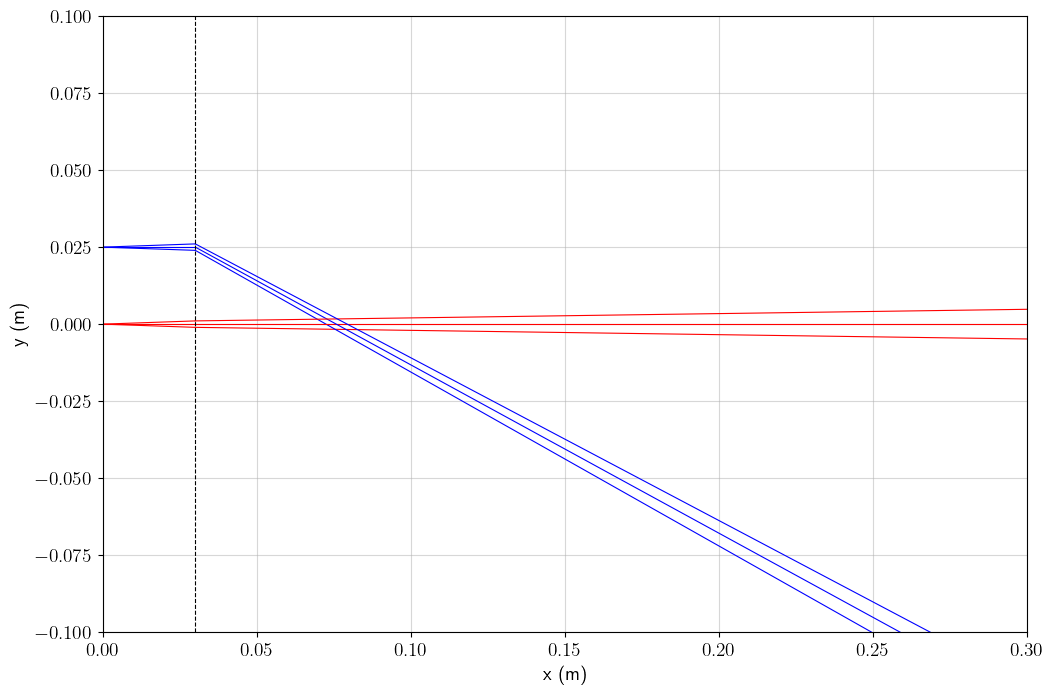

In [99]:
plt.figure(figsize=(12, 8))
for i in range(N):
    plt.plot(xp0[i], yp0[i], 'r', linewidth=0.8)
    plt.plot(xpp0[i], ypp0[i], 'r', linewidth=0.8)
    plt.plot(xp1[i], yp1[i], 'b', linewidth=0.8)
    plt.plot(xpp1[i], ypp1[i], 'b', linewidth=0.8)



plt.plot([d1, d1], [-0.1, 0.1], 'k--', linewidth=0.8, label='Lens plane')

plt.xlim(0, 0.3)
plt.ylim(-0.1, 0.1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid(alpha=0.5)
plt.gca().set_aspect('equal')
plt.show()

### 3.2.4

Modify Code 13 (reflection by a convex mirror) to investigate the formation of a virtual image by a finite-size object.

In [100]:
N = 2
y0 = 0.04
ti = np.linspace(-5, 0, N)
tt = ti * pi/ 180
d1 = 0.3
d2 = 0.3
x0 = 0
R = 0.4

xp = []
xpp = []
xppp = []
yp = []
ypp = []
yppp = []

def propagate(y0, tt, d):
    return y0 + tan(tt)*d

def Spherical_mirror(y, tt, R):
    v1 = np.array([y, tt])
    M = np.array([[1, 0],
                  [2/R, 1]])
    v2 = M @ v1

    return v2


In [101]:

for i in range(N):
    y1 = propagate(y0, tt[i], d1)
    xp.append([x0, d1])
    yp.append([y0, y1])
    y2 = Spherical_mirror(y1, tt[i], R)
    y3 = propagate(y2[0], y2[1], d2)
    xpp.append([d2, x0])
    ypp.append([y2[0], y3])
    y4 = propagate(y2[0], -y2[1],d2 + (R/2))
    xppp.append([d2, d2 + (R/2)])
    yppp.append([y2[0], y4])


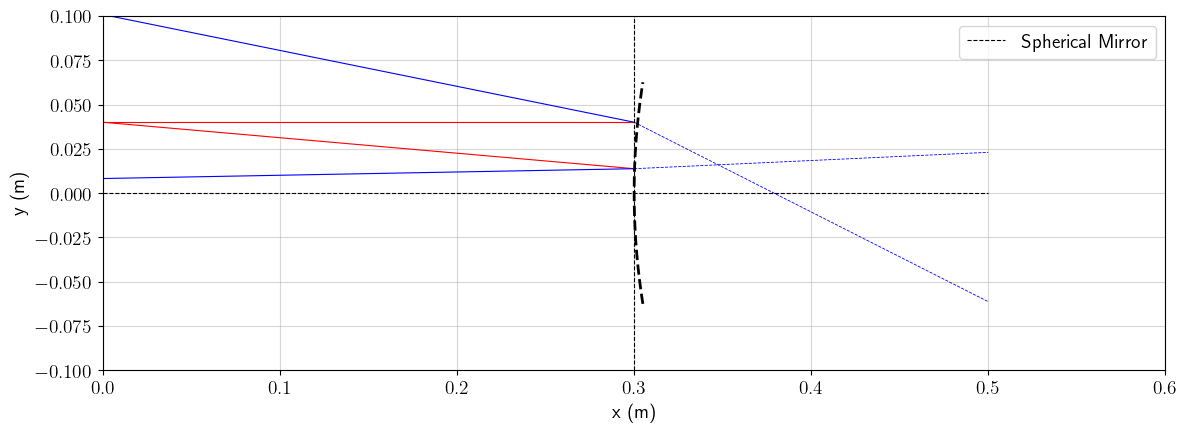

In [102]:
plt.figure(figsize=(12, 8))
for i in range(N):
    plt.plot(xp[i], yp[i], 'r', linewidth=0.8)
    plt.plot(xpp[i], ypp[i], 'b', linewidth=0.8)
    plt.plot(xppp[i], yppp[i], 'b--', linewidth=0.6)


t = np.linspace(-pi/20, pi/20, 1024)   
zc = 0.7
yc = 0


z = zc - R * np.cos(t)
y = yc + R * np.sin(t)


plt.plot(z, y, linewidth=2, linestyle='--', color='k')
plt.plot([d1, d1], [-0.1, 0.1], 'k--', linewidth=0.8, label='Spherical Mirror')
plt.plot([0, 0.5], [0, 0],  'k--', linewidth=0.8)
plt.xlim(0, 0.60)
plt.ylim(-0.1, 0.1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid(alpha=0.5)
plt.gca().set_aspect('equal')
plt.legend()

plt.tight_layout()
plt.show()


### 3.2.6

Through similar analysis, show that when the Fresnel approximation is violated, the wavefront is not necessarily parabolic, and thus spherical aberration sets in and the focal spot is longitudinally extended.

- See *Fundamentals of Photonics*, Chap. 2, p. 56 (Saleh & Teich)

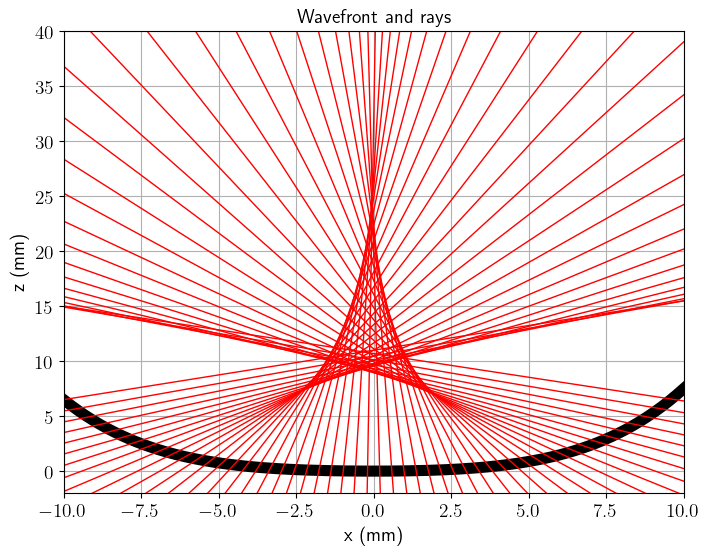

In [ ]:
N = 256
x = np.linspace(-10, 10, N) # making a gird

#-- creating wavefronts
a = [0, 0.0005, 0.0005, 0.02, 0, 0] # poly variables
y = np.polyval(a, x)  # equivalent to 0.0005 * x ^5 + 0.0005 * x ^ 4 + 0.02 * x ^ 2
# plt.plot(x, y)

u = np.diff(y) / np.diff(x) # numerical derivative

M = np.full((N,N), np.nan)
p = 5
for n in range(0, N-1, p):
    slope_normal = -1.0/u[n] # slope_nurmal*u = -1
    q = y[n] + slope_normal*(x - x[n])
    M[:,n] = q

# -- plotting
plt.figure(figsize=(8, 6))
# wavefront (thick black line)
p1, = plt.plot(x, y, 'k-', linewidth=8, label='Wavefront')
# Plot rays each column of M that is not all NaN
for n in range(0, N, p):
    if not np.all(np.isnan(M[:, n])):
        plt.plot(x, M[:, n], 'r-', linewidth=1)

# Axis settings
plt.xlim(-10, 10)
plt.ylim(-2, 40)
plt.xticks(np.arange(-10, 12.5, 2.5))
plt.yticks(np.arange(0, 45, 5))
plt.xlabel('x (mm)')
plt.ylabel('z (mm)')
plt.grid(True)
plt.box(True)
plt.gca().tick_params(labelsize=14)
plt.gca().tick_params(axis='both', which='major', labelsize=14)
plt.gca().set_title('Wavefront and rays', fontsize=14)
plt.show()

### 3.2.7

By comparison of the results of Code 09 (coma aberration), and that of Code 17 (wavefront normals of an arbitrary polynomial wavefront), find the order of the coma aberration in the polynomial function.

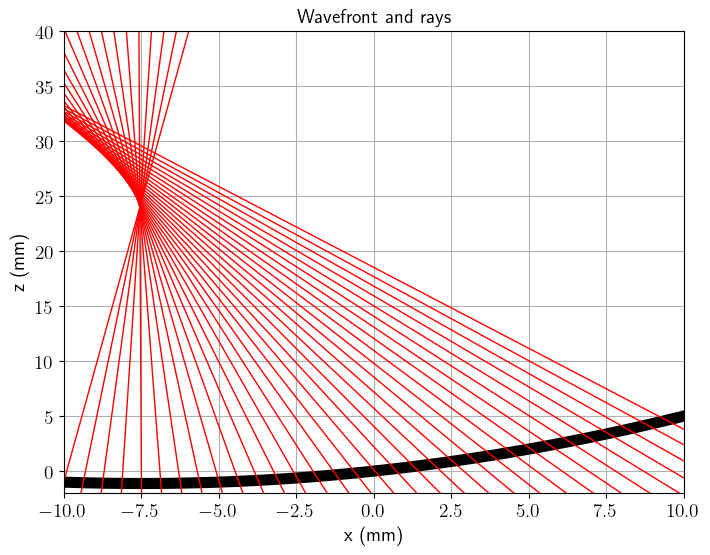

In [135]:
N = 256
x = np.linspace(-10, 10, N) # making a gird

#-- creating wavefronts
a = [0, 0, 0, 0.02, 0.3, 0] # poly variables
y = np.polyval(a, x)  # equivalent to  0.02 * x ^ 2 +  0.3 * x
# plt.plot(x, y)

u = np.diff(y) / np.diff(x) # numerical derivative

M = np.full((N,N), np.nan)
p = 8
for n in range(0, N-1, p):
    slope_normal = -1.0/u[n] # slope_nurmal*u = -1
    q = y[n] + slope_normal*(x - x[n])
    M[:,n] = q

# -- plotting
plt.figure(figsize=(8, 6))
# wavefront (thick black line)
p1, = plt.plot(x, y, 'k-', linewidth=8, label='Wavefront')
# Plot rays each column of M that is not all NaN
for n in range(0, N, p):
    if not np.all(np.isnan(M[:, n])):
        plt.plot(x, M[:, n], 'r-', linewidth=1)

# Axis settings
plt.xlim(-10, 10)
plt.ylim(-2, 40)
plt.xticks(np.arange(-10, 12.5, 2.5))
plt.yticks(np.arange(0, 45, 5))
plt.xlabel('x (mm)')
plt.ylabel('z (mm)')
plt.grid(True)
plt.box(True)
plt.gca().tick_params(labelsize=14)
plt.gca().tick_params(axis='both', which='major', labelsize=14)
plt.gca().set_title('Wavefront and rays', fontsize=14)
plt.show()